# Лабораторная работа 7. FCNN — Регрессия
**Датасет:** `cars_end.csv`, target=`price_usd`

## 1. Импорты

In [2]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import tensorflow as tf
import keras
from keras import layers
import keras_tuner as kt

import ray
from ray import tune as ray_tune
from ray.tune.search.optuna import OptunaSearch

print("TF:", tf.__version__, "| Keras:", keras.__version__, "| Ray:", ray.__version__)


TF: 2.21.0 | Keras: 3.14.1 | Ray: 2.55.1


In [3]:
import sys
print(sys.executable)

x:\Coding\work\ML_labs\lab7\venv\Scripts\python.exe


## 2. Данные

In [4]:
df = pd.read_csv("../lab4/cars_end.csv")
X_raw = df.drop(columns=["price_usd"])
y = df["price_usd"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

sel = SelectKBest(f_regression, k=30)
X = sel.fit_transform(X_scaled, y)

print("Признаков после отбора:", X.shape[1])

SEED = 42
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print("Train:", X_tr.shape, "| Test:", X_te.shape)


Признаков после отбора: 30
Train: (30792, 30) | Test: (7699, 30)


## 3. Scikit-learn MLP

### Вспомогательная функция

In [5]:
results = []

def eval_reg(model, label, optimizer):
    r = {}
    for tag, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        p = model.predict(X)
        r[tag] = {"R2": r2_score(y, p),
                  "MSE": mean_squared_error(y, p),
                  "MAE": mean_absolute_error(y, p)}
    print(f"{label:40s} | train R2={r['train']['R2']:.3f} | test R2={r['test']['R2']:.3f}")
    results.append({"Модель": label, "Оптимизатор": optimizer,
                    **{f"train_{k}": v for k, v in r["train"].items()},
                    **{f"test_{k}": v for k, v in r["test"].items()}})
    return r


### 3.1 Optuna

In [6]:
def objective(trial):
    m = MLPRegressor(
        hidden_layer_sizes=(trial.suggest_int("h1", 32, 256),
                            trial.suggest_int("h2", 16, 128)),
        activation=trial.suggest_categorical("activation", ["relu", "tanh"]),
        solver=trial.suggest_categorical("solver", ["adam", "lbfgs"]),
        alpha=trial.suggest_float("alpha", 1e-5, 1e-2, log=True),
        learning_rate_init=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        max_iter=500, random_state=42)
    return -cross_val_score(m, X_tr, y_tr, cv=kf, scoring="r2").mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

p = study.best_params
m_optuna = MLPRegressor(hidden_layer_sizes=(p["h1"], p["h2"]),
                         activation=p["activation"], solver=p["solver"],
                         alpha=p["alpha"], learning_rate_init=p["lr"],
                         max_iter=500, random_state=42)
m_optuna.fit(X_tr, y_tr)
eval_reg(m_optuna, "sklearn Optuna", p["solver"])


sklearn Optuna                           | train R2=0.907 | test R2=0.878


{'train': {'R2': 0.9067161736989202,
  'MSE': 3868677.232115269,
  'MAE': 1252.993240091526},
 'test': {'R2': 0.8780346814733992,
  'MSE': 4932190.559589712,
  'MAE': 1355.2496393254055}}

### 3.2 RandomizedSearchCV

In [7]:
param_dist = {
    "hidden_layer_sizes": [(64,32),(128,64),(256,128),(128,64,32)],
    "activation": ["relu","tanh"],
    "solver": ["adam","sgd","lbfgs"],
    "alpha": uniform(1e-5, 1e-2),
    "learning_rate_init": uniform(1e-4, 1e-2),
}
rs = RandomizedSearchCV(MLPRegressor(max_iter=500, random_state=42),
                         param_dist, n_iter=15, cv=kf,
                         scoring="r2", random_state=42, n_jobs=-1)
rs.fit(X_tr, y_tr)
eval_reg(rs.best_estimator_, "sklearn RandomSearch", rs.best_params_["solver"])


sklearn RandomSearch                     | train R2=0.928 | test R2=0.873


{'train': {'R2': 0.927968442485354,
  'MSE': 2987300.7744268207,
  'MAE': 1146.963814343286},
 'test': {'R2': 0.8730310738032692,
  'MSE': 5134532.887823978,
  'MAE': 1353.279696264929}}

### 3.3 Hyperopt

In [8]:
space = {
    "h1": hp.choice("h1", [64, 128, 256]),
    "h2": hp.choice("h2", [32, 64, 128]),
    "activation": hp.choice("activation", ["relu","tanh"]),
    "solver": hp.choice("solver", ["adam","sgd","lbfgs"]),
    "alpha": hp.loguniform("alpha", np.log(1e-5), np.log(1e-2)),
    "lr": hp.loguniform("lr", np.log(1e-4), np.log(1e-2)),
}

def hyperopt_obj(params):
    m = MLPRegressor(hidden_layer_sizes=(params["h1"], params["h2"]),
                     activation=params["activation"], solver=params["solver"],
                     alpha=params["alpha"], learning_rate_init=params["lr"],
                     max_iter=500, random_state=42)
    return {"loss": -cross_val_score(m, X_tr, y_tr, cv=3, scoring="r2").mean(),
            "status": STATUS_OK}

best = fmin(hyperopt_obj, space, algo=tpe.suggest, max_evals=10,
            trials=Trials(), rstate=np.random.default_rng(42))

solvers = ["adam","lbfgs"]
activations = ["relu","tanh"]
sizes = [64,128,256]; sizes2 = [32,64,128]
m_hp = MLPRegressor(hidden_layer_sizes=(sizes[best["h1"]], sizes2[best["h2"]]),
                     activation=activations[best["activation"]],
                     solver=solvers[best["solver"]],
                     alpha=best["alpha"], learning_rate_init=best["lr"],
                     max_iter=500, random_state=42)
m_hp.fit(X_tr, y_tr)
eval_reg(m_hp, "sklearn Hyperopt", solvers[best["solver"]])


100%|██████████| 10/10 [30:13<00:00, 181.32s/trial, best loss: -0.8840476042127102]
sklearn Hyperopt                         | train R2=0.928 | test R2=0.878


{'train': {'R2': 0.9275851496679485,
  'MSE': 3003196.736832395,
  'MAE': 1130.3918679942826},
 'test': {'R2': 0.8782018259236104,
  'MSE': 4925431.357142837,
  'MAE': 1345.9291809094693}}

## 4. Keras + TensorFlow

In [9]:
N = X_tr.shape[1]
EPOCHS = 30
CB = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

def build(units1=64, units2=32, optimizer="adam", lr=1e-3):
    m = keras.Sequential([
        layers.Input(shape=(N,)),
        layers.Dense(units1, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(units2, activation="relu"),
        layers.Dense(1)
    ])
    opt = {"adam": keras.optimizers.Adam(lr),
           "sgd":  keras.optimizers.SGD(lr),
           "rmsprop": keras.optimizers.RMSprop(lr)}[optimizer]
    m.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return m

def plot_history(h, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.history["loss"], label="train")
    axes[0].plot(h.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    axes[1].plot(h.history["mae"], label="train")
    axes[1].plot(h.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE"); axes[1].legend()
    plt.tight_layout(); plt.show()

def eval_keras(model, label, optimizer):
    p_tr = model.predict(X_tr, verbose=0).flatten()
    p_te = model.predict(X_te, verbose=0).flatten()
    r = {"train": {"R2": r2_score(y_tr, p_tr),
                   "MSE": mean_squared_error(y_tr, p_tr),
                   "MAE": mean_absolute_error(y_tr, p_tr)},
         "test":  {"R2": r2_score(y_te, p_te),
                   "MSE": mean_squared_error(y_te, p_te),
                   "MAE": mean_absolute_error(y_te, p_te)}}
    print(f"{label:40s} | train R2={r['train']['R2']:.3f} | test R2={r['test']['R2']:.3f}")
    results.append({"Модель": label, "Оптимизатор": optimizer,
                    **{f"train_{k}": v for k, v in r["train"].items()},
                    **{f"test_{k}": v for k, v in r["test"].items()}})


### 4.1 Базовые модели (Adam / SGD / RMSprop)

In [11]:
_orig_build = build

def build(units1=64, units2=32, optimizer="adam", lr=1e-3):
    if optimizer == "sgd":
        lr = lr * 0.1
    return _orig_build(units1, units2, optimizer, lr)

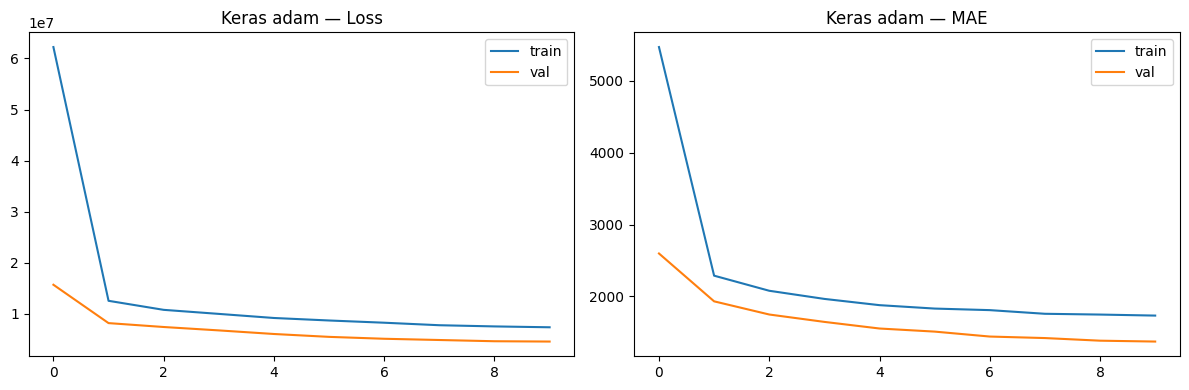

Keras adam                               | train R2=0.591 | test R2=0.601


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,805 (50.02 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 8,452 (33.02 KB)

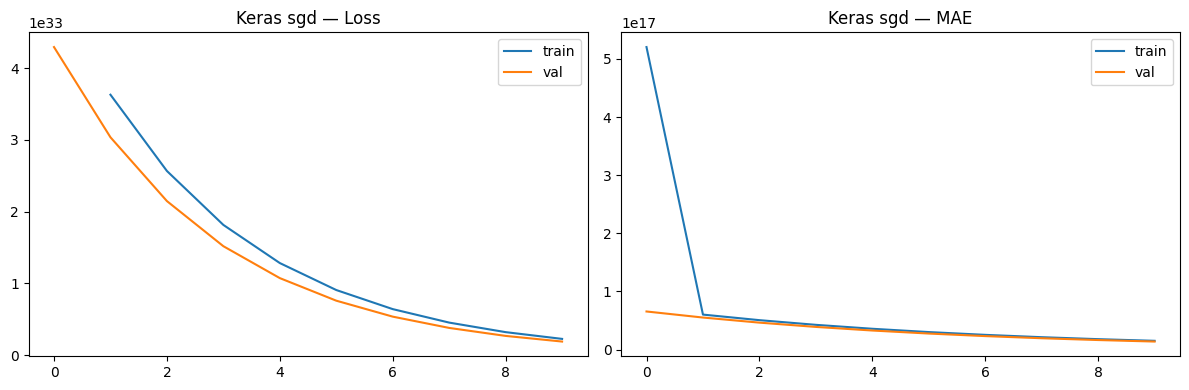

Keras sgd                                | train R2=-103515916459579635824328704.000 | test R2=-106159724825752665740804096.000


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,355 (17.02 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 2 (12.00 B)

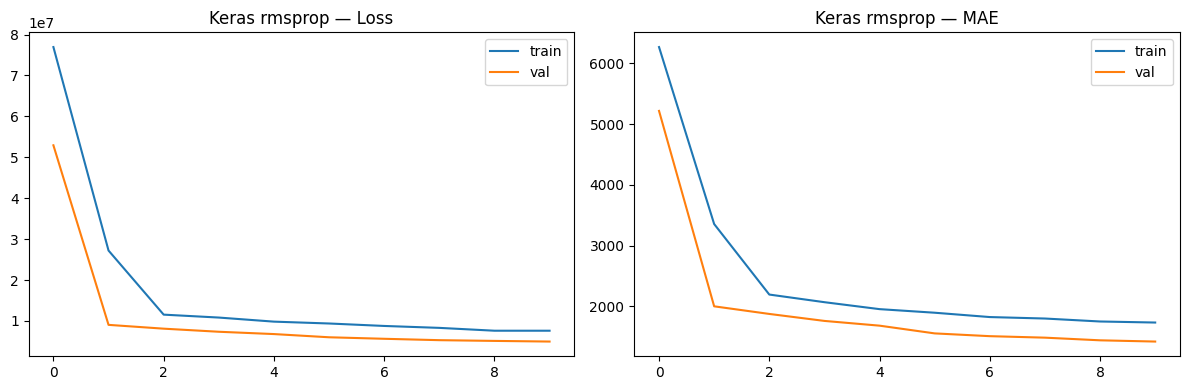

Keras rmsprop                            | train R2=-0.329 | test R2=-0.319


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,580 (33.52 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 4,227 (16.52 KB)

In [12]:
for opt_name in ["adam", "sgd", "rmsprop"]:
    m = build(optimizer=opt_name)
    h = m.fit(X_tr, y_tr, validation_split=0.1,
              epochs=EPOCHS, callbacks=CB, verbose=0)
    plot_history(h, f"Keras {opt_name}")
    eval_keras(m, f"Keras {opt_name}", opt_name)
    m.summary()


### 4.2 Optuna

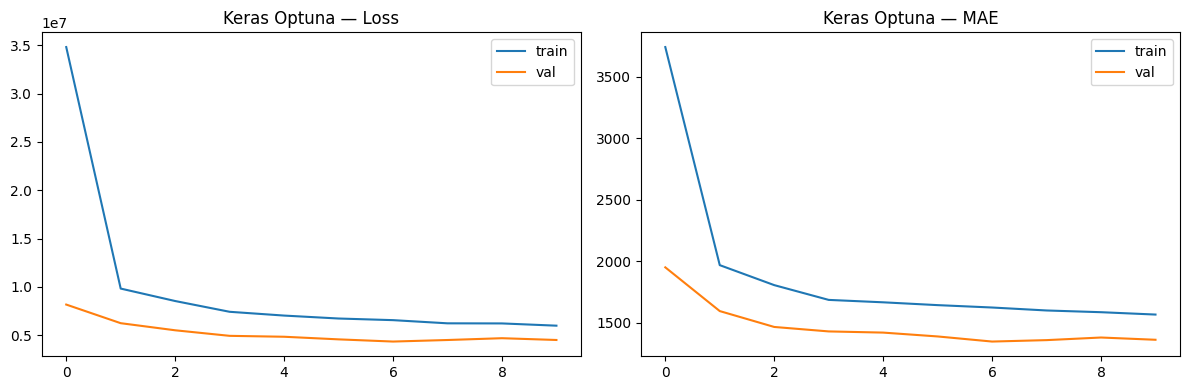

Keras Optuna                             | train R2=0.788 | test R2=0.788


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,397 (294.52 KB)

 Trainable params: 24,961 (97.50 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 49,924 (195.02 KB)

In [14]:
def obj_kr(trial):
    m = build(trial.suggest_categorical("u1", [64,128,256]),
              trial.suggest_categorical("u2", [32,64,128]),
              trial.suggest_categorical("opt", ["adam","rmsprop"]),
              trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    h = m.fit(X_tr, y_tr, validation_split=0.1, epochs=20, callbacks=CB, verbose=0)
    return min(h.history["val_loss"])

study_k = optuna.create_study(direction="minimize")
study_k.optimize(obj_kr, n_trials=8)
p = study_k.best_params
m_ko = build(p["u1"], p["u2"], p["opt"], p["lr"])
h = m_ko.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "Keras Optuna")
eval_keras(m_ko, "Keras Optuna", p["opt"])
m_ko.summary()


### 4.3 KerasTuner

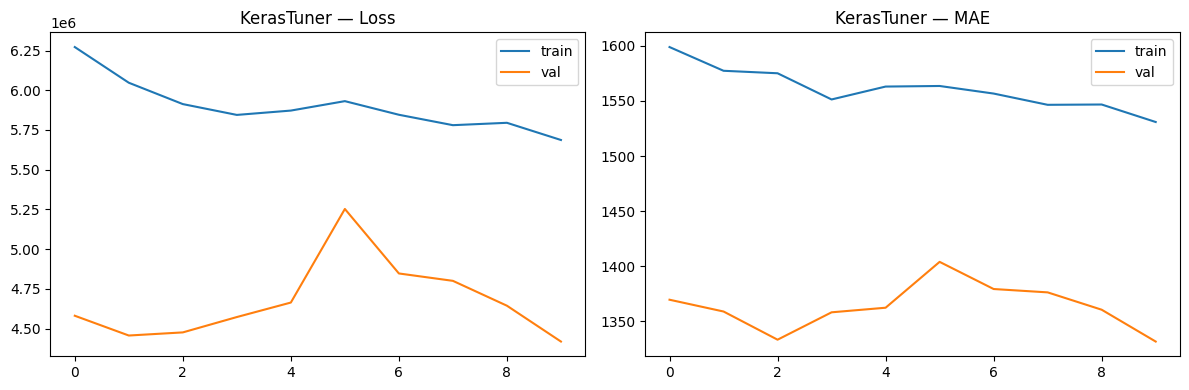

KerasTuner                               | train R2=0.884 | test R2=0.858


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,629 (197.77 KB)

 Trainable params: 16,705 (65.25 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 33,412 (130.52 KB)

In [16]:
def kt_model(hp):
    return build(hp.Choice("u1", [64,128,256]),
                 hp.Choice("u2", [32,64,128]),
                 hp.Choice("opt", ["adam","sgd","rmsprop"]),
                 hp.Float("lr", 1e-4, 1e-2, sampling="log"))

tuner = kt.RandomSearch(kt_model, objective="val_loss", max_trials=10, seed=42,
                         directory="kt_reg", project_name="lab7_reg", overwrite=True)
tuner.search(X_tr, y_tr, validation_split=0.1, epochs=50, callbacks=CB, verbose=0)
best_m = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
h = best_m.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "KerasTuner")
eval_keras(best_m, "KerasTuner", best_hp.get("opt"))
best_m.summary()


### 4.4 Ray Tune

2026-05-28 00:57:41,788	WARNING optuna_search.py:570 -- The value nan is not acceptable
2026-05-28 00:58:15,090	WARNING optuna_search.py:570 -- The value nan is not acceptable
2026-05-28 00:58:26,014	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to 'C:/Users/nikit/ray_results/ray_train_2026-05-28_00-57-19' in 0.0106s.


Лучший конфиг: {'u1': 64, 'u2': 32, 'opt': 'adam', 'lr': 0.0035878816472785903}


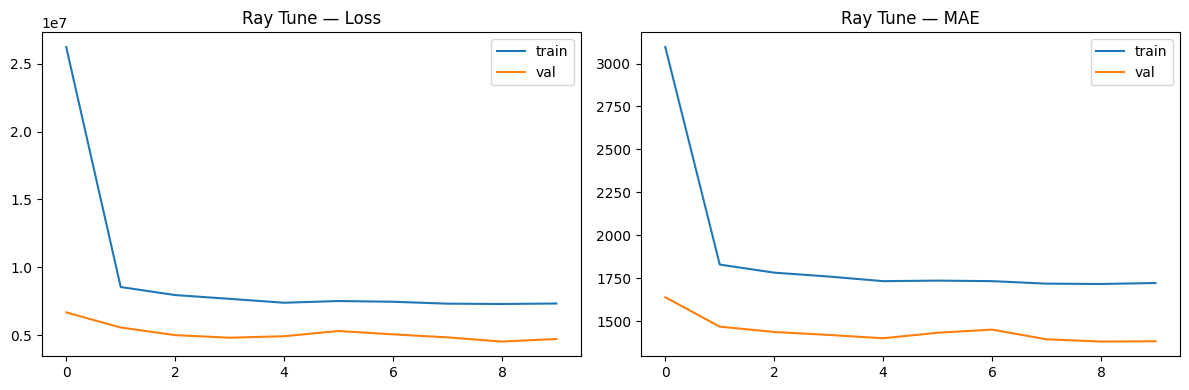

Ray Tune                                 | train R2=0.825 | test R2=0.825


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,805 (50.02 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 8,452 (33.02 KB)

In [17]:
ray.init(ignore_reinit_error=True, log_to_driver=False)

def ray_train(config):
    m = build(config["u1"], config["u2"], config["opt"], config["lr"])
    h = m.fit(X_tr, y_tr, validation_split=0.1, epochs=50, callbacks=CB, verbose=0)
    ray_tune.report({"val_loss": min(h.history["val_loss"])})

analysis = ray_tune.run(
    ray_train,
    config={"u1": ray_tune.choice([64,128,256]),
            "u2": ray_tune.choice([32,64,128]),
            "opt": ray_tune.choice(["adam","sgd","rmsprop"]),
            "lr": ray_tune.loguniform(1e-4, 1e-2)},
    search_alg=OptunaSearch(metric="val_loss", mode="min"),
    num_samples=5, verbose=0)

cfg = analysis.get_best_config("val_loss", "min")
print("Лучший конфиг:", cfg)
m_ray = build(cfg["u1"], cfg["u2"], cfg["opt"], cfg["lr"])
h = m_ray.fit(X_tr, y_tr, validation_split=0.1, epochs=EPOCHS, callbacks=CB, verbose=0)
plot_history(h, "Ray Tune")
eval_keras(m_ray, "Ray Tune", cfg["opt"])
m_ray.summary()


## 5. Сводная таблица метрик

In [18]:
df_res = pd.DataFrame(results).round(4)
display(df_res)


,Модель,Оптимизатор,train_R2,train_MSE,train_MAE,test_R2,test_MSE,test_MAE
0,sklearn Optuna,adam,9.067000e-01,3.868677e+06,1.252993e+03,8.780000e-01,4.932191e+06,1.355250e+03
1,sklearn RandomSearch,lbfgs,9.280000e-01,2.987301e+06,1.146964e+03,8.730000e-01,5.134533e+06,1.353280e+03
2,sklearn Hyperopt,adam,9.276000e-01,3.003197e+06,1.130392e+03,8.782000e-01,4.925431e+06,1.345929e+03
3,Keras adam,adam,8.850000e-01,4.768228e+06,1.343643e+03,8.637000e-01,5.510757e+06,1.384740e+03
4,Keras adam,adam,5.913000e-01,1.695063e+07,2.643675e+03,6.008000e-01,1.614357e+07,2.600575e+03
5,Keras sgd,sgd,-1.035159e+26,4.293024e+33,6.552117e+16,-1.061597e+26,4.293024e+33,6.552117e+16
6,Keras rmsprop,rmsprop,-3.295000e-01,5.513634e+07,5.276166e+03,-3.186000e-01,5.332316e+07,5.185280e+03
7,Keras Optuna,adam,7.883000e-01,8.780322e+06,1.972259e+03,7.883000e-01,8.559201e+06,1.948665e+03
8,KerasTuner,adam,8.838000e-01,4.819224e+06,1.368005e+03,8.584000e-01,5.728030e+06,1.432695e+03
9,Ray Tune,adam,8.255000e-01,7.237011e+06,1.652997e+03,8.254000e-01,7.060686e+06,1.632572e+03


## 6. Деплой — пример предсказания

In [19]:
sample = X_te[[0]]
pred = m_optuna.predict(sample)[0]
print(f"Предсказанная цена: {pred:,.0f} USD")
print(f"Реальная цена:      {y_te[0]:,.0f} USD")


Предсказанная цена: 6,133 USD
Реальная цена:      5,800 USD


## 7. Вывод

В ходе работы были реализованы и сравнены два подхода к построению регрессионных моделей: классические алгоритмы sklearn (MLPRegressor) и нейронные сети на основе Keras, с применением различных методов подбора гиперпараметров (Optuna, RandomizedSearchCV, Hyperopt, KerasTuner, Ray Tune).

Лучшие результаты показали модели на основе sklearn: все три метода поиска гиперпараметров дали схожее качество — R² ≈ 0.878 на тестовой выборке при MAE ≈ 1346–1355. Это свидетельствует об устойчивости MLPRegressor при правильно подобранных параметрах.

Среди Keras-моделей наилучший результат продемонстрировала архитектура, настроенная с помощью KerasTuner (R² = 0.858), что незначительно уступает sklearn. Модели с оптимизатором Adam в целом сходились стабильно. Оптимизатор SGD показал катастрофический результат (R² ≈ −10²⁶) из-за взрывного градиента при отсутствии клипирования — это подтверждает необходимость использования адаптивных оптимизаторов или нормализации градиентов при работе с данной задачей. RMSprop также не сошёлся (R² = −0.319).

Таким образом, для данной регрессионной задачи оптимальным выбором является MLPRegressor (sklearn) с подбором гиперпараметров через Optuna или Hyperopt. Keras-подход сопоставим по качеству при использовании Adam, однако требует более тщательной настройки обучения.